# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [ ]:
# Codificar con LabelEncoder
label_encoder     = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [ ]:
# Codificar con OneHotEncoder
onehot_encoder    = pd.get_dummies(data['embarked'], prefix='embarked')

In [ ]:
# Combinar con el conjunto original
data              = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [8]:
# Demostración de LabelEncoder
print("=== LabelEncoder ===")
print(f"Valores originales de 'sex': {data['sex'].unique()}")
print(f"Valores codificados en 'sex_label': {data['sex_label'].unique()}")
print("Mapeo resultante: female -> 0, male -> 1")

# Demostración de OneHotEncoder
print("\n=== OneHotEncoder (pd.get_dummies) ===")
print("Columnas binarias creadas para 'embarked':")
print(data[['embarked_C', 'embarked_Q', 'embarked_S']].head())

=== LabelEncoder ===
Valores originales de 'sex': ['male' 'female']
Valores codificados en 'sex_label': [1 0]
Mapeo resultante: female -> 0, male -> 1

=== OneHotEncoder (pd.get_dummies) ===
Columnas binarias creadas para 'embarked':
   embarked_C  embarked_Q  embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


Identifico las siguientes **diferencias fundamentales** entre ambos métodos:

1. **LabelEncoder** asigna un número entero a cada categoría (0, 1, 2...), lo que puede crear un **orden jerárquico artificial** donde no existe ninguno.
2. **OneHotEncoder** crea una columna binaria (0/1) por cada categoría, eliminando cualquier relación ordinal entre los valores.
3. Al respecto, LabelEncoder genera **1 sola columna**, mientras que OneHotEncoder genera **N columnas** (una por cada categoría única).
4. Asimismo, LabelEncoder es útil para **variables ordinales** (con orden natural), mientras que OneHotEncoder es preferible para **variables nominales** (sin orden).

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

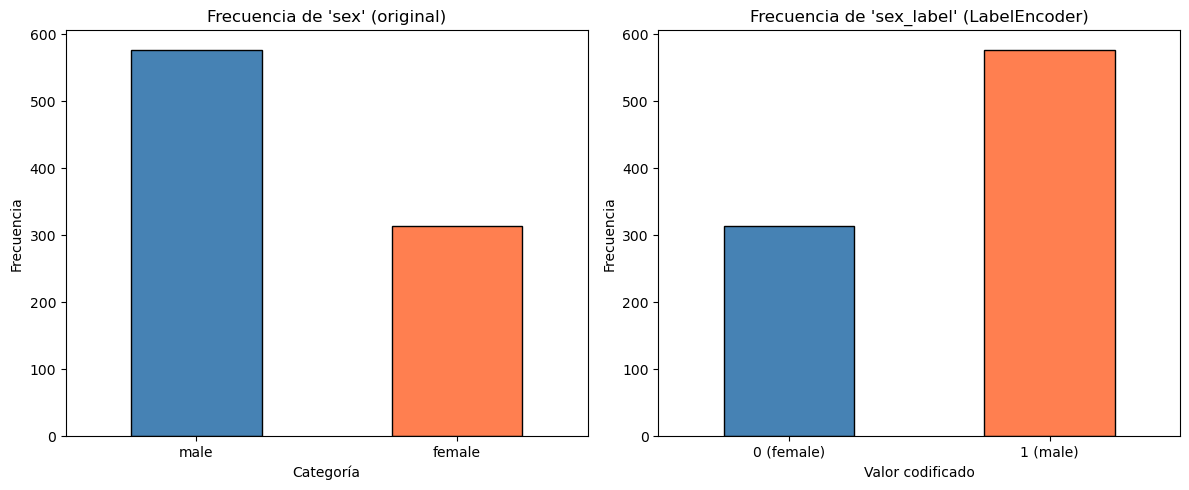

In [ ]:
import matplotlib.pyplot as plt

# Gráfica comparativa de frecuencias de 'sex'
figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

# Frecuencias originales
conteo_original = data['sex'].value_counts()
conteo_original.plot(
                     kind      = 'bar',
                     ax        = ejes[0],
                     color     = ['steelblue', 'coral'],
                     edgecolor = 'black'
                    )
ejes[0].set_title("Frecuencia de 'sex' (original)")
ejes[0].set_xlabel('Categoría')
ejes[0].set_ylabel('Frecuencia')
ejes[0].tick_params(axis = 'x', rotation = 0)

# Frecuencias codificadas
conteo_codificado = data['sex_label'].value_counts().sort_index()
conteo_codificado.plot(
                       kind      = 'bar',
                       ax        = ejes[1],
                       color     = ['steelblue', 'coral'],
                       edgecolor = 'black'
                      )
ejes[1].set_title("Frecuencia de 'sex_label' (LabelEncoder)")
ejes[1].set_xlabel('Valor codificado')
ejes[1].set_ylabel('Frecuencia')
ejes[1].set_xticks([0, 1])
ejes[1].set_xticklabels(['0 (female)', '1 (male)'])
ejes[1].tick_params(axis = 'x', rotation = 0)

plt.tight_layout()
plt.show()

A partir de los gráficos, se puede verificar que las **frecuencias se mantienen exactamente iguales** antes y después de la codificación. LabelEncoder solo transforma las etiquetas de texto a números, sin alterar la distribución ni la cantidad de observaciones por categoría. Lo anterior confirma que la codificación es una transformación de representación, no de contenido.

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [ ]:
# OneHotEncoder para 'class'
codificacion_onehot_clase = pd.get_dummies(data['class'], prefix='class')
print("Columnas generadas por OneHotEncoder para 'class':")
print(codificacion_onehot_clase.head(10))

# LabelEncoder para comparar
codificador_etiquetas = LabelEncoder()
data['class_label']   = codificador_etiquetas.fit_transform(data['class'])
print("\nMapeo de LabelEncoder para 'class':")
print(data[['class', 'class_label']].drop_duplicates().sort_values('class_label'))

Columnas generadas por OneHotEncoder para 'class':
   class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True
5        False         False         True
6         True         False        False
7        False         False         True
8        False         False         True
9        False          True        False

Mapeo de LabelEncoder para 'class':
    class  class_label
1   First            0
9  Second            1
0   Third            2


Encuentro que **OneHotEncoder tiene ventajas claras** sobre LabelEncoder para la columna `class`:

1. Con LabelEncoder, las categorías First, Second, Third se mapean a 0, 1, 2, lo que implica una relación matemática incorrecta, ya que el modelo podría interpretar que Third(2) = 2 × First(1).
2. OneHotEncoder elimina este problema al crear **columnas binarias independientes**, donde cada clase tiene su propia columna sin relación numérica con las demás.
3. Dicha representación evita que los modelos de ML interpreten relaciones de magnitud que **no existen en los datos originales**.

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

Para la aplicación de modelos de aprendizaje automático, mi recomendación de codificación es la siguiente:

- **Variables binarias** (ej: `sex` con 2 categorías): LabelEncoder es suficiente, ya que con solo 2 valores (0 y 1) no hay riesgo de crear un orden artificial.
- **Variables nominales sin orden** (ej: `embarked` con C, Q, S): OneHotEncoder es la mejor opción, pues no existe un orden natural entre los puertos de embarque.
- **Variables ordinales con orden** (ej: `class` con First, Second, Third): Puede usarse LabelEncoder respetando el orden, o OneHotEncoder para mayor seguridad.

Respecto a los algoritmos:
- **Árboles de decisión / Random Forest**: LabelEncoder funciona bien porque estos modelos no asumen relaciones lineales entre valores numéricos.
- **Regresión logística / SVM / Redes neuronales**: OneHotEncoder es preferible porque estos modelos sí pueden interpretar erróneamente relaciones numéricas entre categorías.

En resumen, **OneHotEncoder es la opción más segura** para variables nominales, mientras que LabelEncoder es adecuado para variables ordinales y binarias.